In [1]:
from tqdm.auto import tqdm
import glob
import re
from pathlib import Path
import os
import numpy as np


In [2]:
"""
Example line:
/usr/project/xtmp/bsc32/droid/GuptaLab/Smith_Hall_Fetch_Lab/9934859632/Thu_Apr_20_14:51:30_2023/16291792/000007.png, [{'name': 'shipping label', 'class': 1, 'confidence': 0.47822, 'box': {'x1': 745.70288, 'y1': 0.0, 'x2': 839.38086, 'y2': 377.07367}, 'segments': {'x': [764.0, 764.0, 762.0, 762.0, 760.0, 760.0, 758.0, 758.0, 756.0, 756.0, 754.0, 754.0, 752.0, 752.0, 750.0, 750.0, 748.0, 748.0, 746.0, 740.0, 740.0, 842.0, 842.0, 836.0, 834.0, 834.0, 832.0, 832.0, 830.0, 830.0], 'y': [0.0, 2.0, 4.0, 8.0, 10.0, 16.0, 18.0, 24.0, 26.0, 32.0, 34.0, 42.0, 44.0, 68.0, 70.0, 122.0, 124.0, 150.0, 152.0, 152.0, 378.0, 378.0, 18.0, 18.0, 16.0, 14.0, 12.0, 6.0, 4.0, 0.0]}}]
Path structure: /usr/project/xtmp/bsc32/droid/lab/building/scene_id/...
"""


class_names = []
with open("yoloe_custom_mapping.txt", "r") as f:
    for line in f:
        if line.strip():
            class_names.append(" ".join(line.strip().split(" ")[1:]))

print(f"Class Names: {class_names}")

# Precompile a regex to extract names
name_pattern = re.compile(r"'name':\s*'([^']+)'")

# get list of (lab_name, building, scene_id, file_path) tuples for each "name" category
file_paths = {name: [] for name in class_names}

# glob names from droid dir
lab_names = glob.glob("/usr/project/xtmp/bsc32/droid/*")
lab_names = [lab_path.split("/")[-1] for lab_path in lab_names if not lab_path.endswith(".txt")]

for lab_name in tqdm(lab_names, desc="Processing labs", position=0, mininterval=0.5, dynamic_ncols=True):
    with open(f"/usr/project/xtmp/bsc32/droid_yoloe/{lab_name}/predictions.txt", "r") as f:
        lines = f.readlines()
        for line in tqdm(lines, desc=f"Processing {lab_name}", position=1, leave=True, mininterval=0.5, dynamic_ncols=True):
            line_parts = line.strip().split(", ", 1)
            file_path = line_parts[0]
            detections_str = line_parts[1]
            if detections_str and detections_str != "[]":
                # Extract lab, building, and scene_id from path
                # Path format: /usr/project/xtmp/bsc32/droid/lab/building/scene_id/...
                path_parts = file_path.split("/")
                lab = path_parts[6]  # lab name
                building = path_parts[7]  # building name
                scene_id = path_parts[8]  # scene_id
                
                # Fast path: extract names via regex without parsing JSON
                # Also extract confidence values
                conf_pattern = re.compile(r"'confidence':\s*([0-9]*\.?[0-9]+)")
                names = name_pattern.findall(detections_str)
                confs = conf_pattern.findall(detections_str)
                # If confidence list length differs from names, pad with None or align best-effort
                if len(confs) != len(names):
                    # best-effort: repeat last confidence or use None
                    if len(confs) == 0:
                        confs = [None] * len(names)
                    elif len(confs) < len(names):
                        confs = confs + [confs[-1]] * (len(names) - len(confs))
                for name, conf in zip(names, confs):
                    if name in file_paths:
                        # store as a dict so we can extend later with more metadata
                        file_paths[name].append({
                            'lab': lab,
                            'building': building,
                            'scene_id': scene_id,
                            'file_path': file_path,
                            'confidence': float(conf) if conf is not None else None
                        })


Class Names: ['barcode', 'shipping label', 'QR code', 'sign', 'room sign', 'handwritten text', 'printed text', 'whiteboard', 'calendar', 'person', 'cardboard box', 'painting', 'poster', 'portrait', 'drawing', 'photograph']


Processing labs:   0%|          | 0/13 [00:00<?, ?it/s]

Processing REAL:   0%|          | 0/92204 [00:00<?, ?it/s]

Processing RAIL:   0%|          | 0/117835 [00:00<?, ?it/s]

Processing AUTOLab:   0%|          | 0/128511 [00:00<?, ?it/s]

...

Processing RPL:   0%|          | 0/38281 [00:00<?, ?it/s]

Processing PennPAL:   0%|          | 0/54790 [00:00<?, ?it/s]

Processing WEIRD:   0%|          | 0/23978 [00:00<?, ?it/s]

Processing RAD:   0%|          | 0/23123 [00:00<?, ?it/s]

Processing GuptaLab:   0%|          | 0/18872 [00:00<?, ?it/s]

In [3]:

def extract_thresholded_values(file_paths, c=0.5):
    thresholded_paths = {}
    for name in file_paths:
        thresholded_entries = []
        for entry in file_paths[name]:
            conf = entry.get('confidence', None)
            if conf is not None and conf >= c:
                thresholded_entries.append(entry)
        thresholded_paths[name] = thresholded_entries
    return thresholded_paths

file_paths = extract_thresholded_values(file_paths, c=0.5)


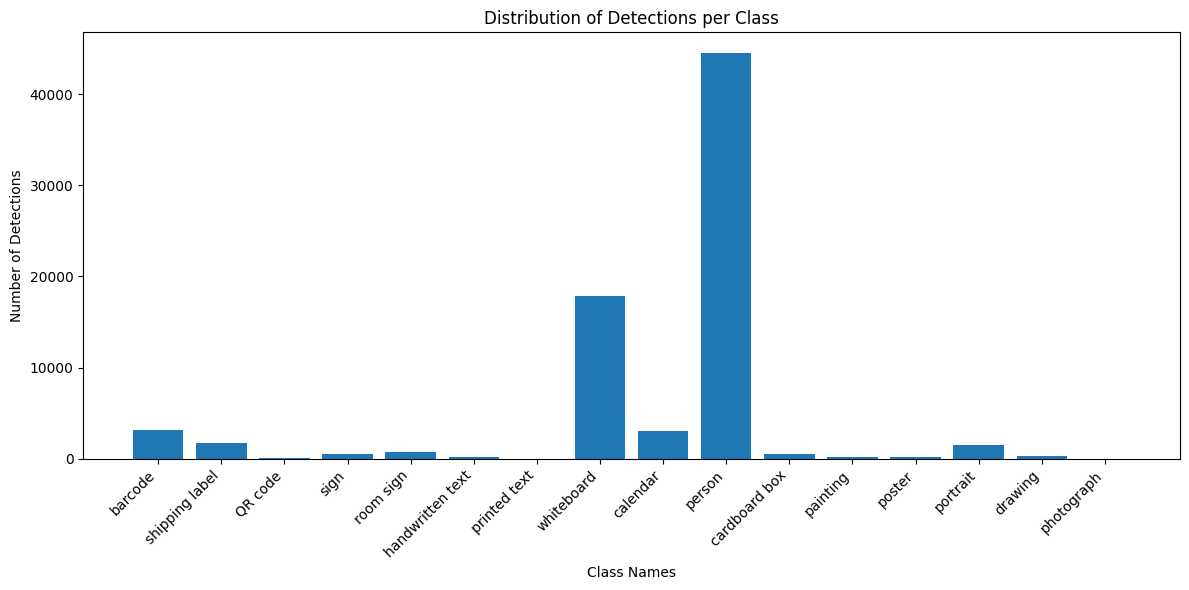

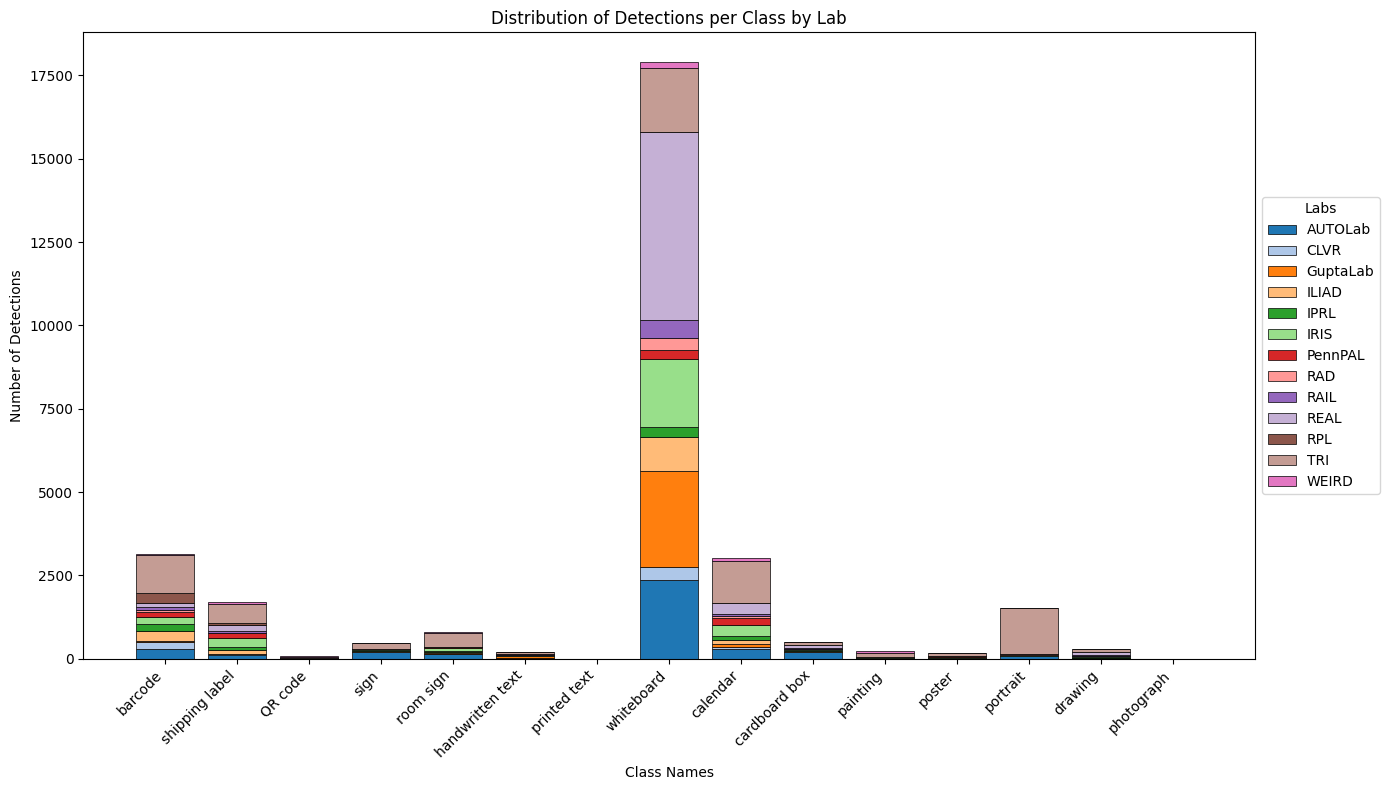

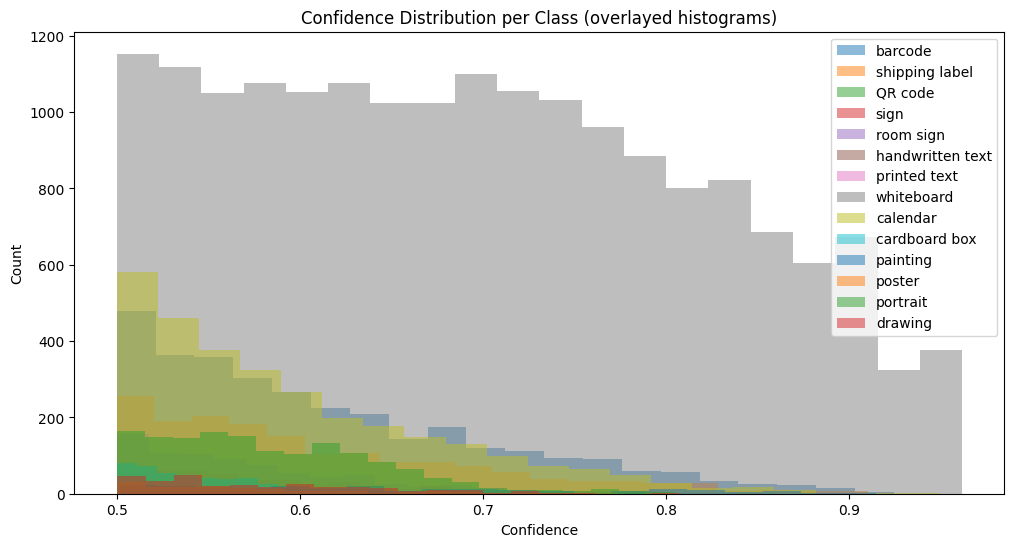

In [4]:
# plot distributions
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
counts = [len(file_paths[name]) for name in class_names]
plt.bar(class_names, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Class Names")
plt.ylabel("Number of Detections")
plt.title("Distribution of Detections per Class")
plt.tight_layout()
plt.show()

# stacked bar charts to show lab per class distribution
# stacked bar charts to show lab per class distribution using the tab20 (20-color) palette
class_names = [name for name in class_names if name != "person"]
lab_list = sorted(list(set(fp['lab'] for fps in file_paths.values() for fp in fps)))
labs = lab_list
colors = [plt.cm.tab20(i % 20) for i in range(len(labs))]
stack_bottom = np.zeros(len(class_names))
plt.figure(figsize=(14, 8))
for i, lab in enumerate(labs):
    counts = [sum(1 for fp in file_paths[name] if fp['lab'] == lab) for name in class_names]
    plt.bar(class_names, counts, bottom=stack_bottom, label=lab, color=colors[i], edgecolor='black', linewidth=0.5)
    stack_bottom += np.array(counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Class Names")
plt.ylabel("Number of Detections")
plt.title("Distribution of Detections per Class by Lab")
plt.legend(title="Labs", bbox_to_anchor=(1, 0.5), loc='center left')
plt.tight_layout()
plt.show()

# show confidence distributions for each class
plt.figure(figsize=(12, 6))
for name in class_names:
    confs = [fp['confidence'] for fp in file_paths[name] if fp['confidence'] is not None]
    if len(confs) == 0:
        continue
    plt.hist(confs, bins=20, alpha=0.5, label=name)
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.title('Confidence Distribution per Class (overlayed histograms)')
plt.legend()
plt.show()


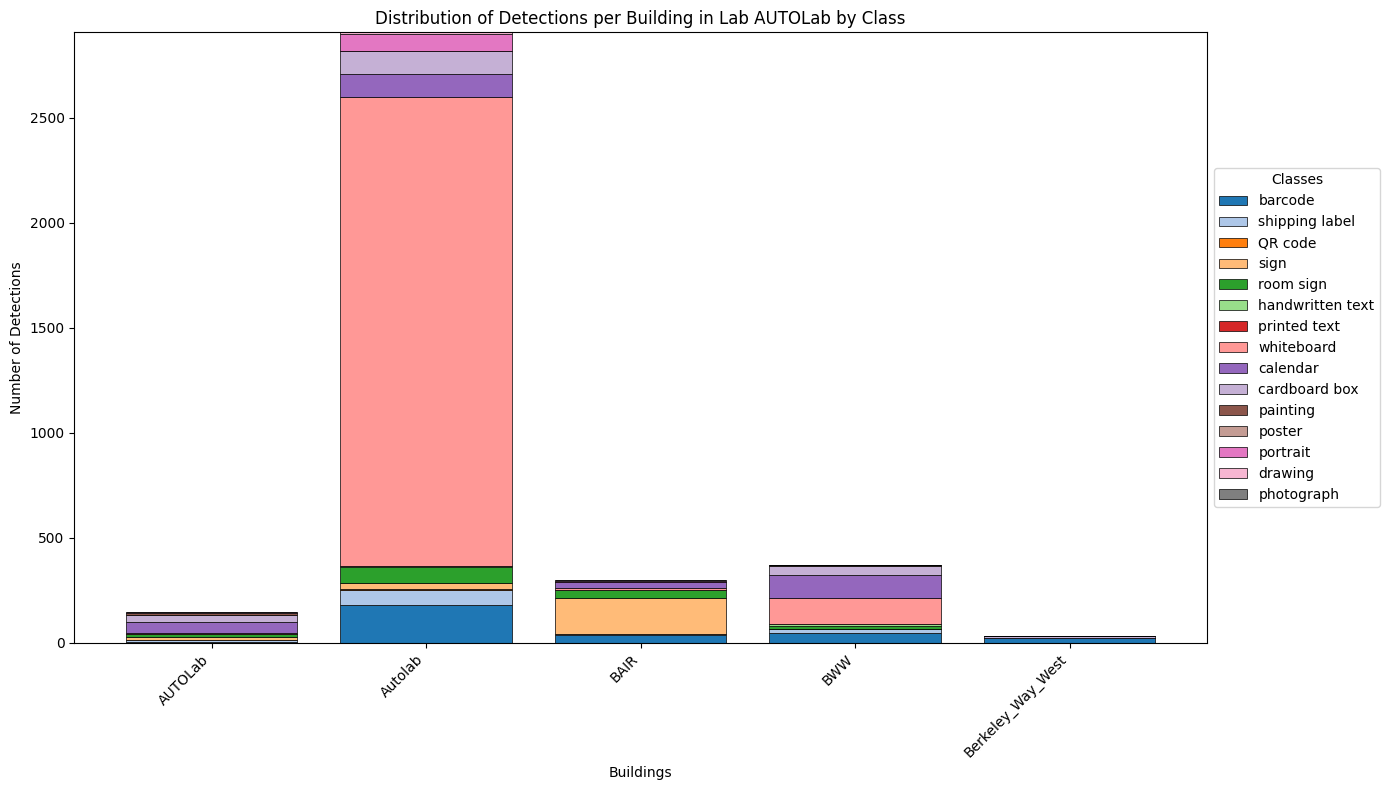

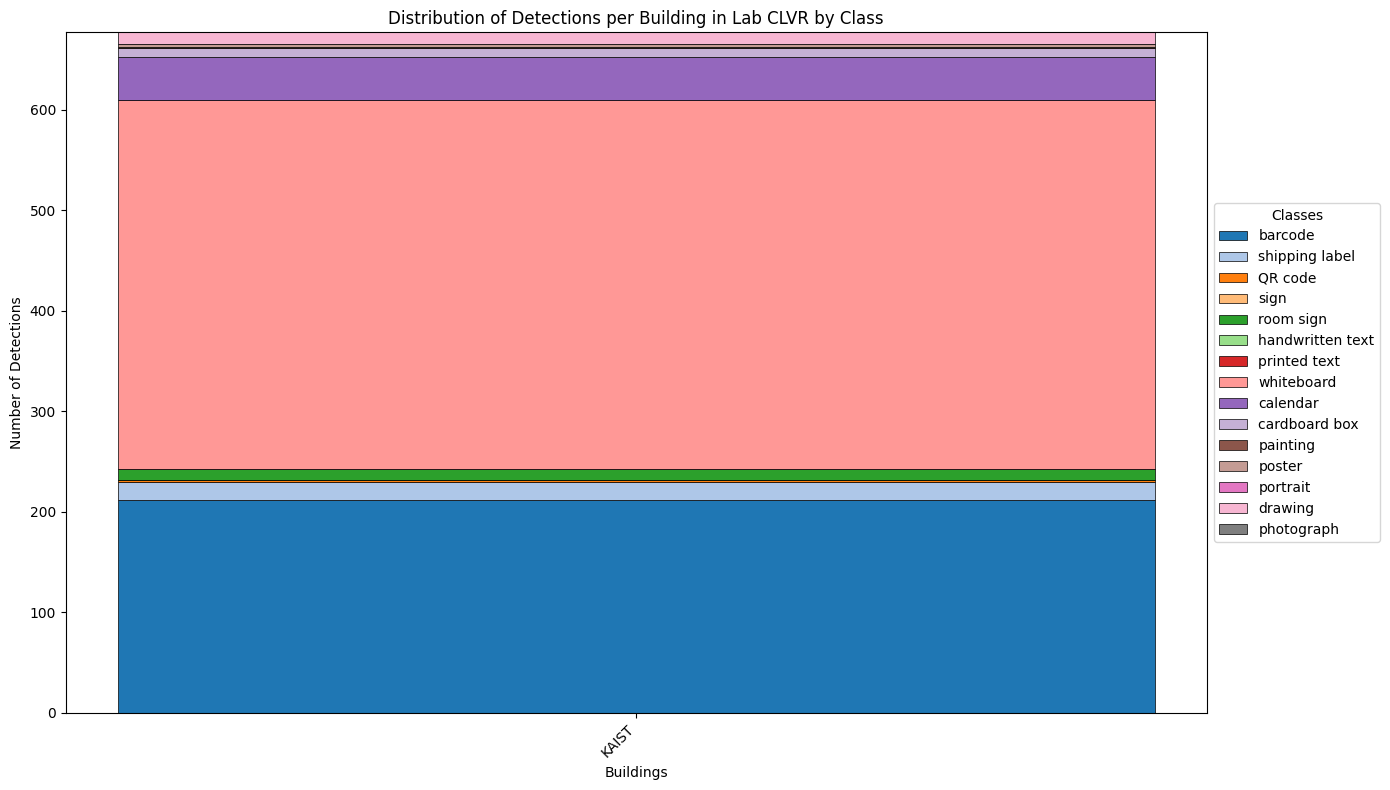

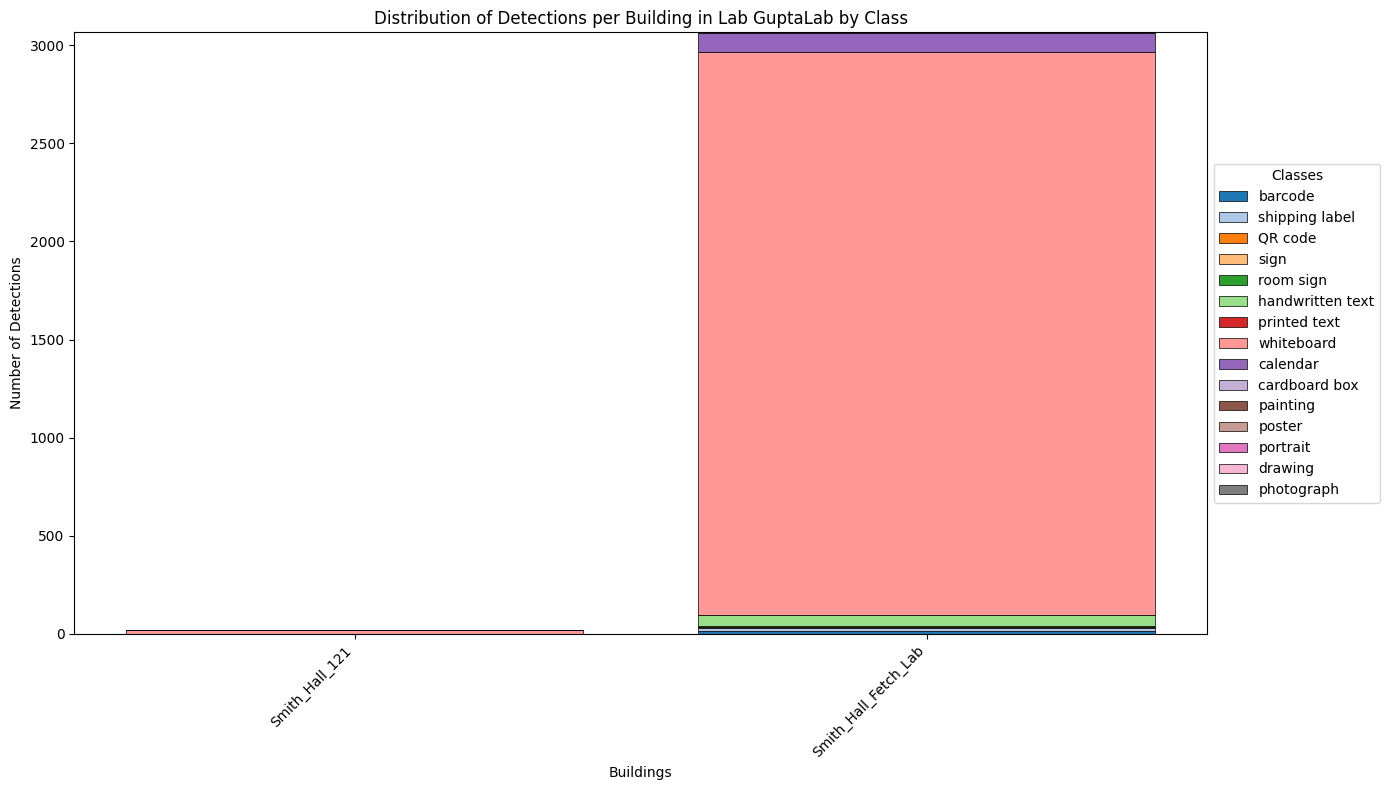

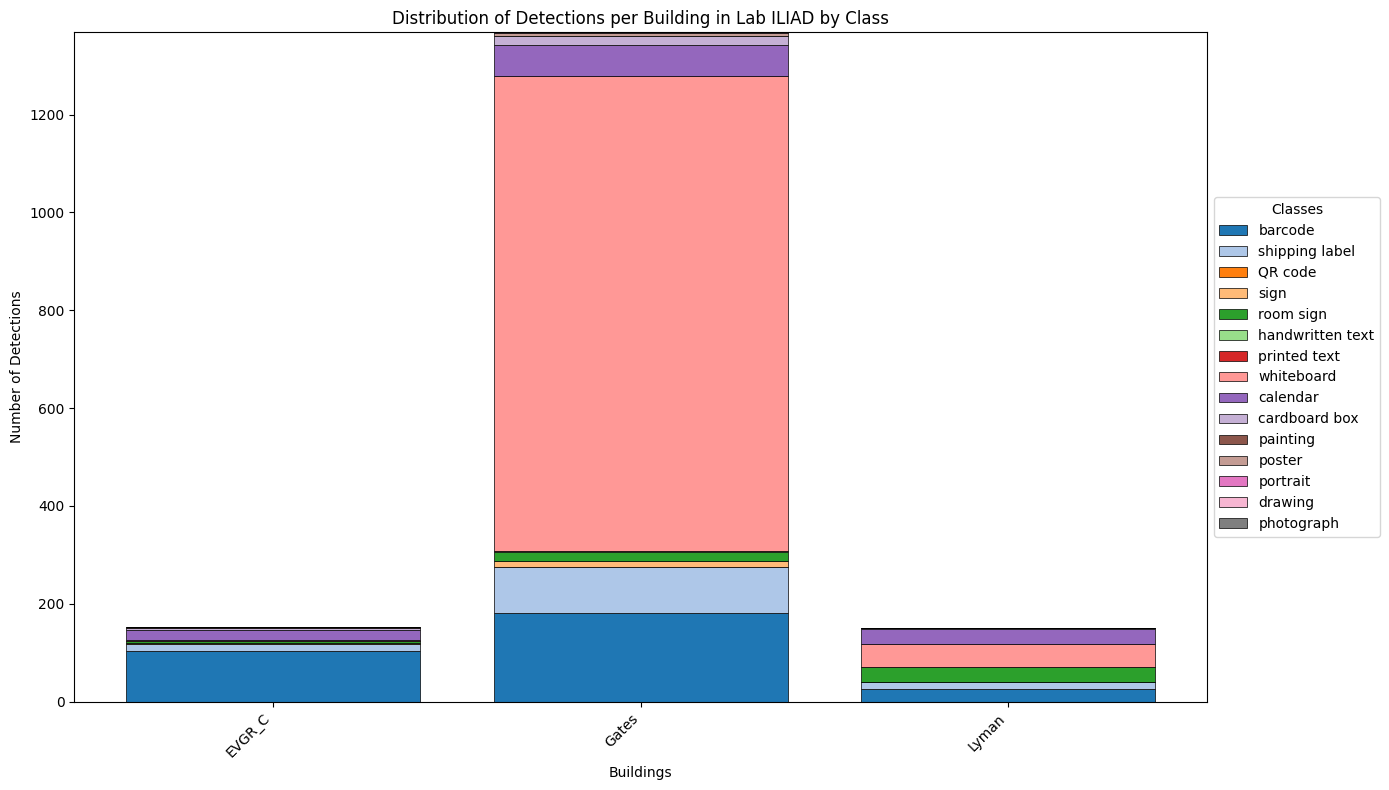

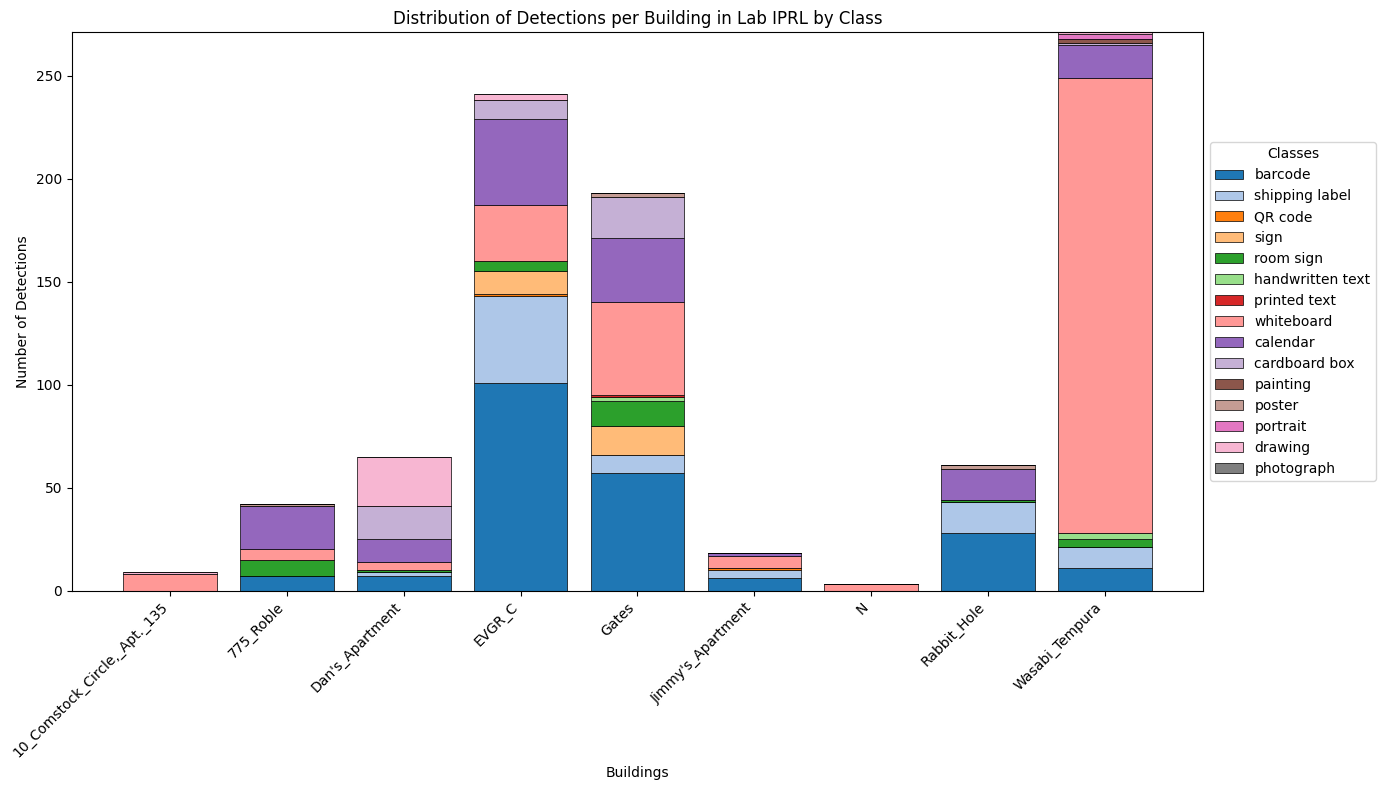

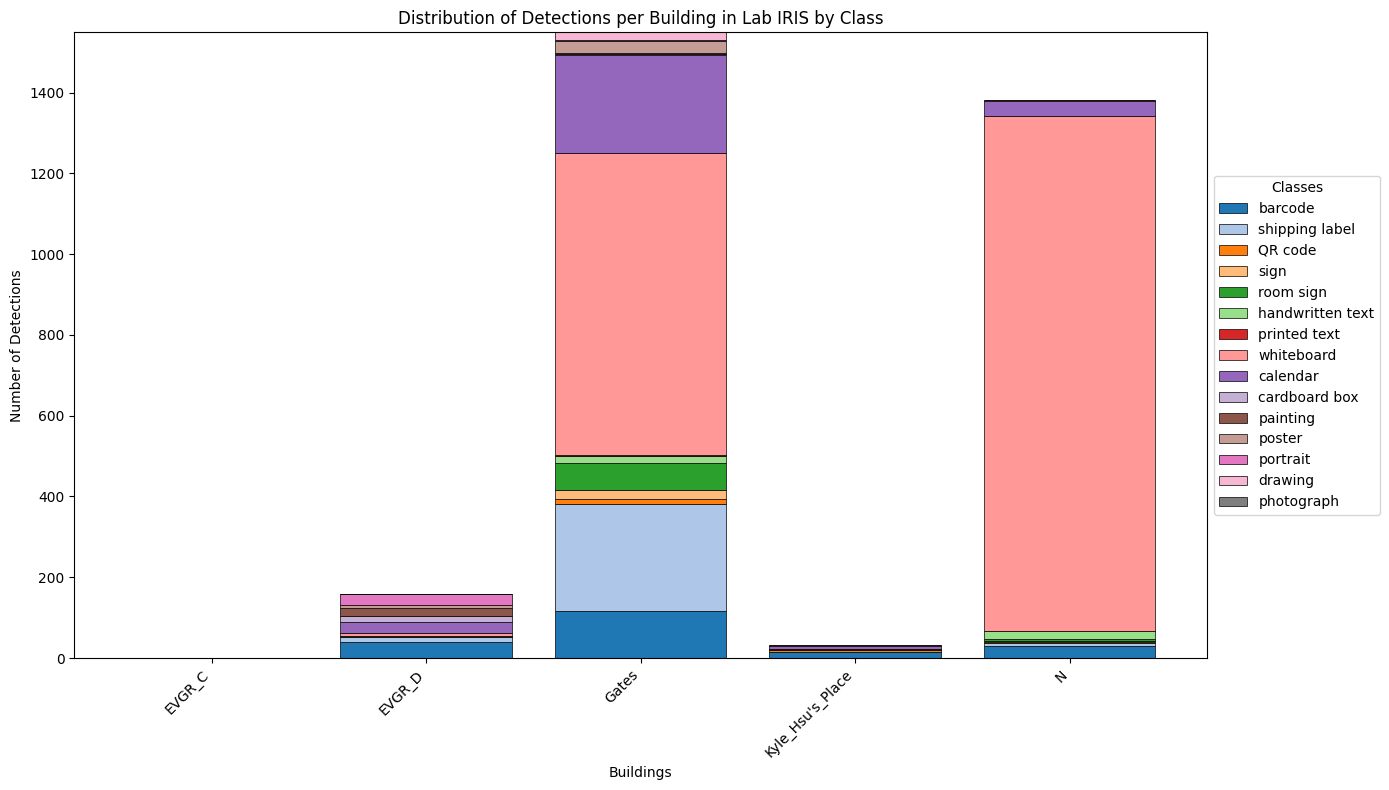

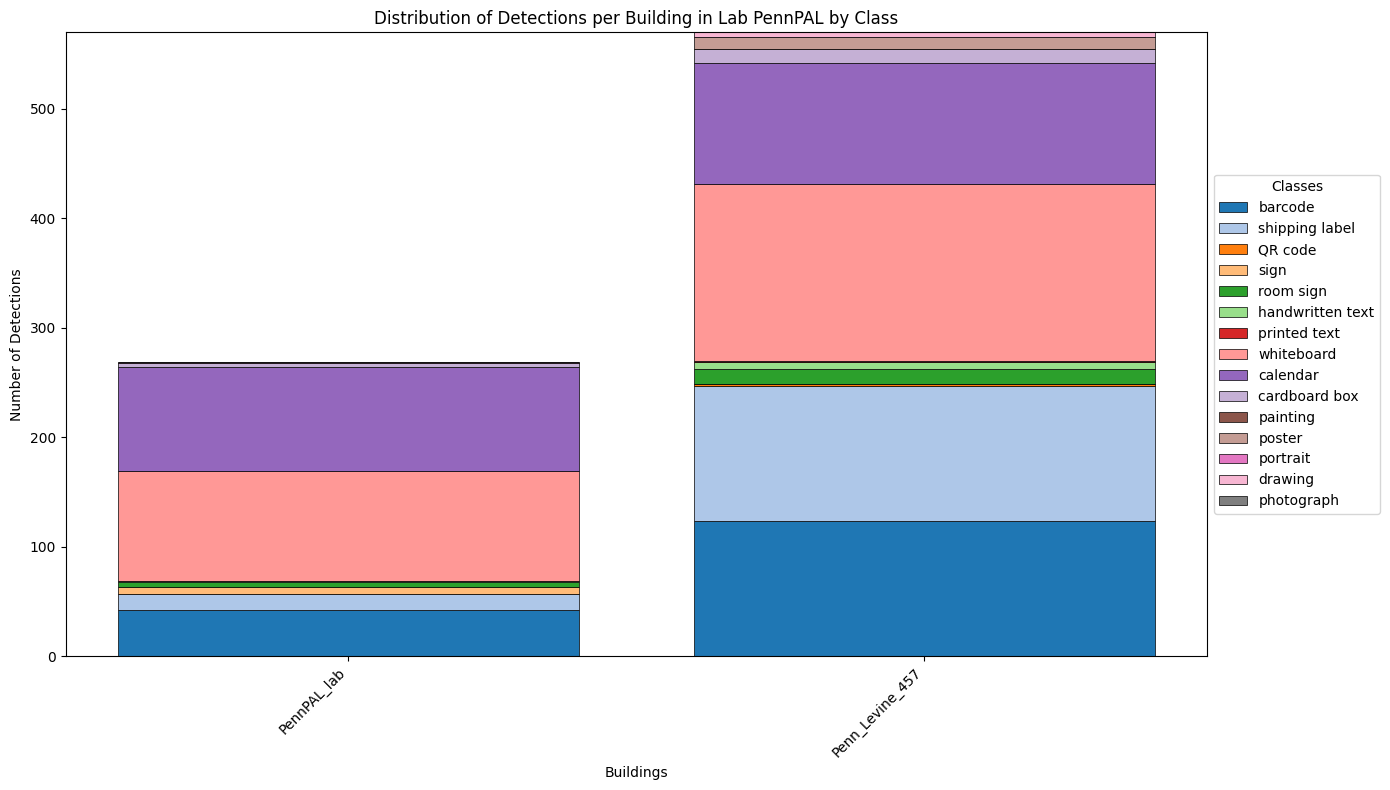

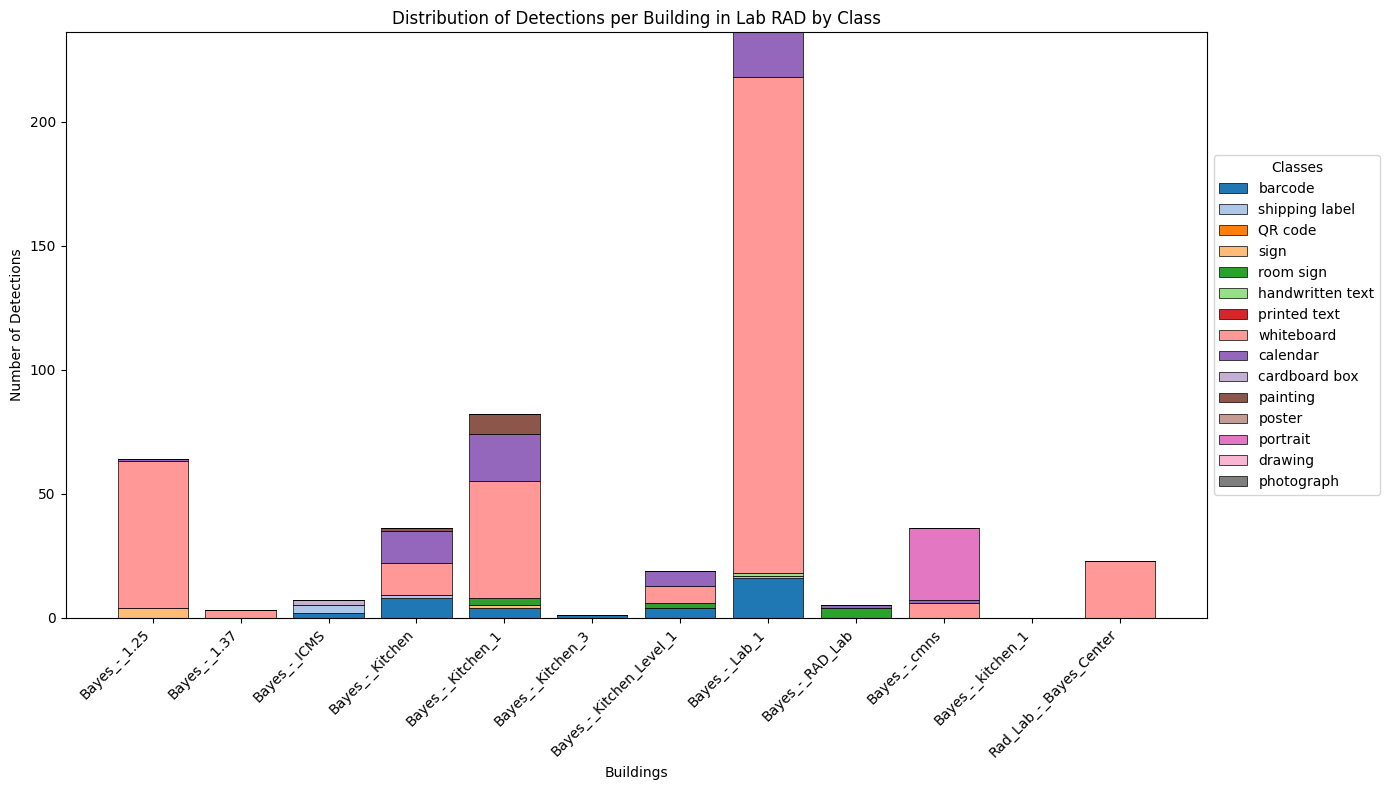

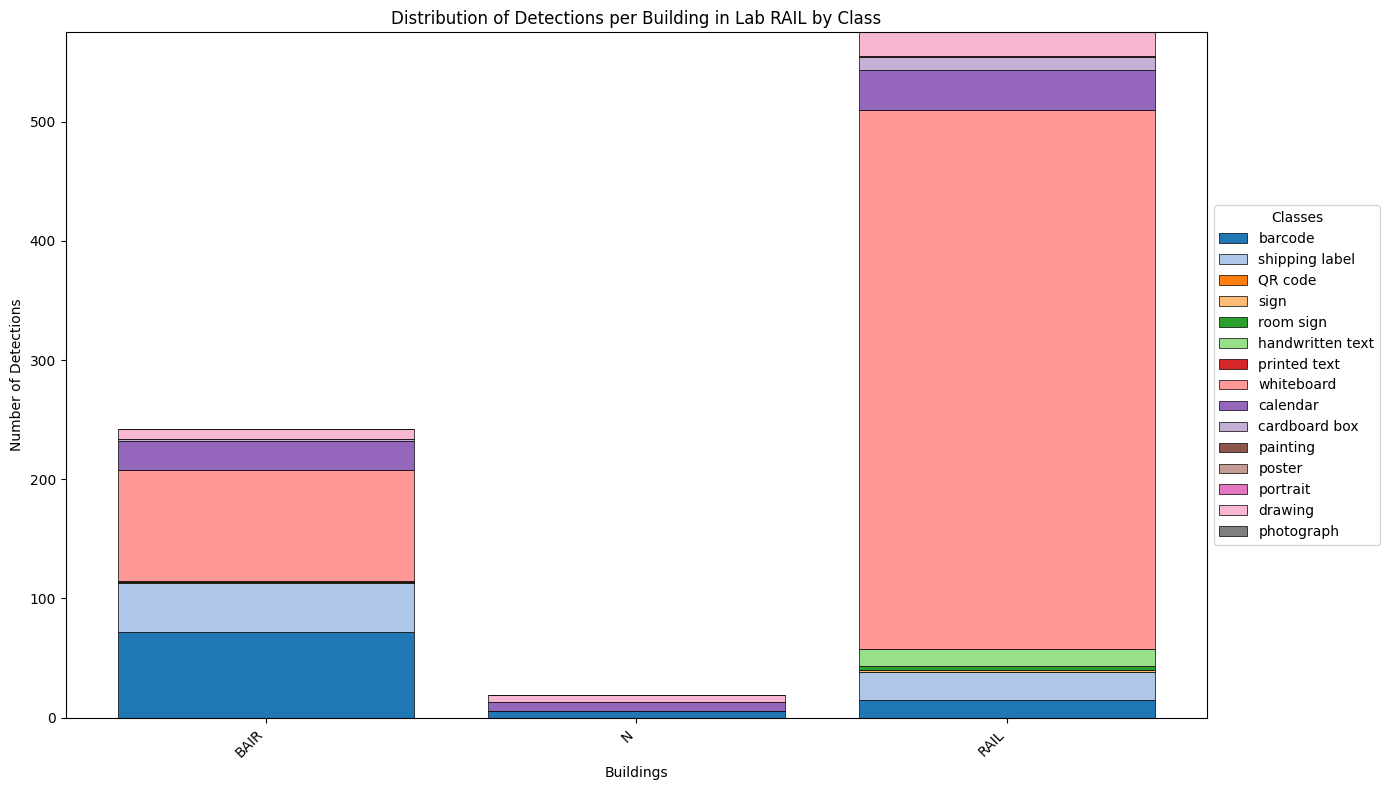

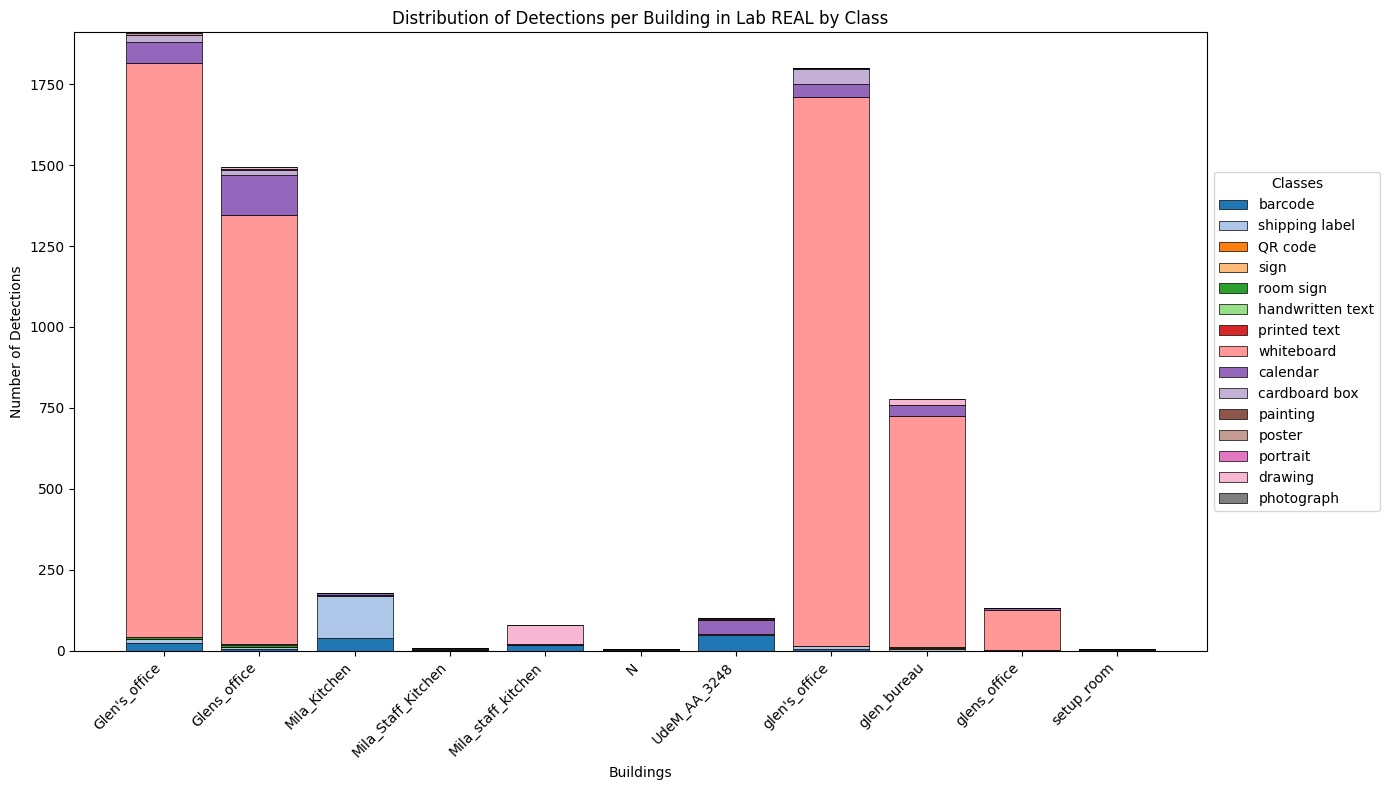

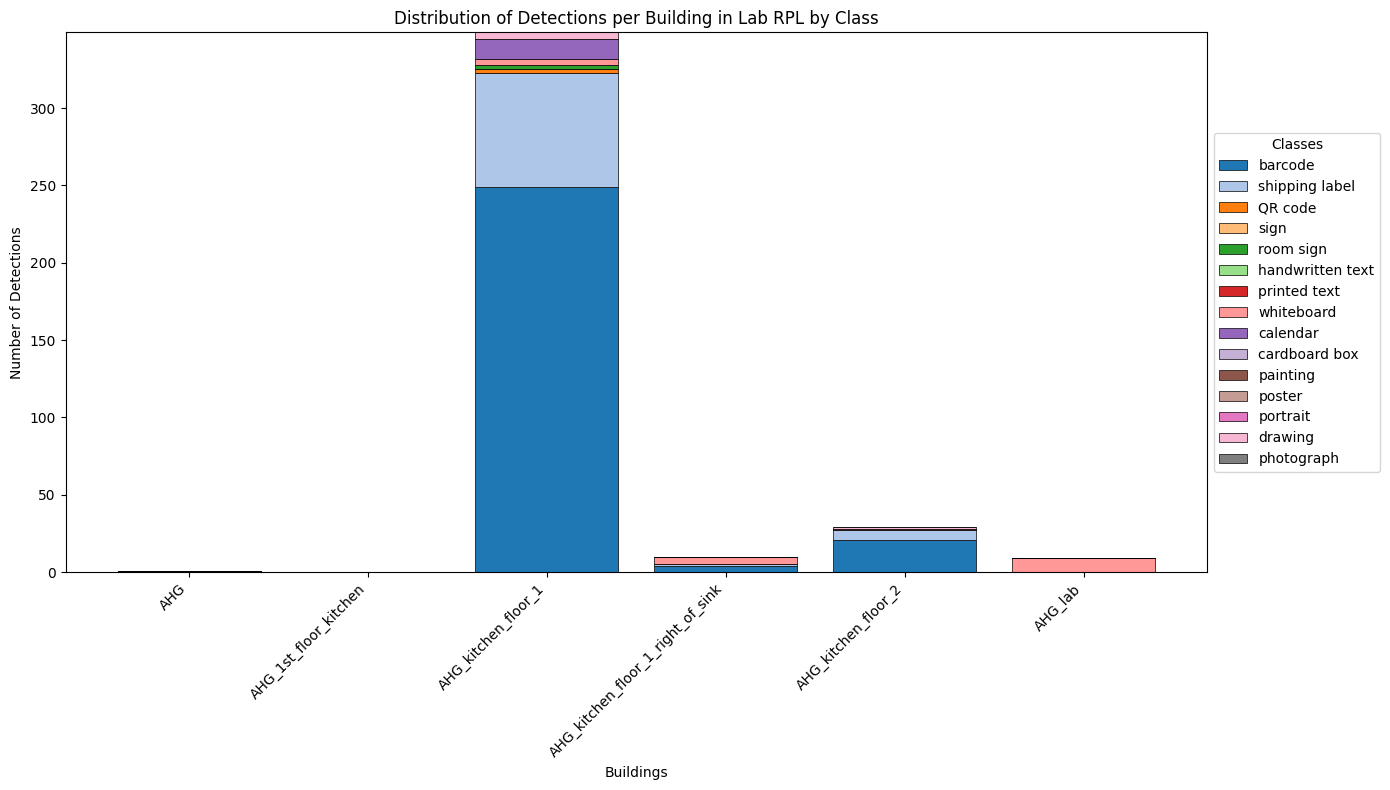

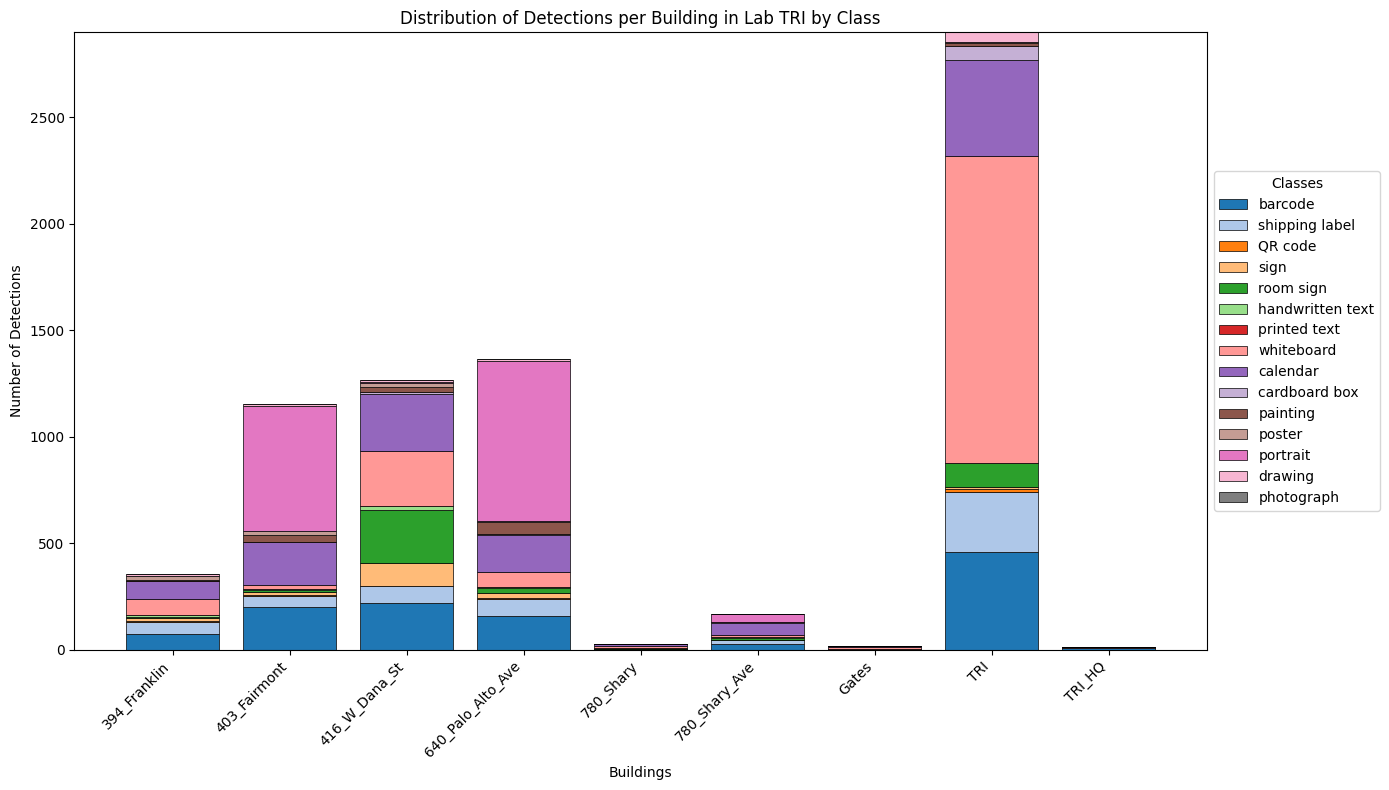

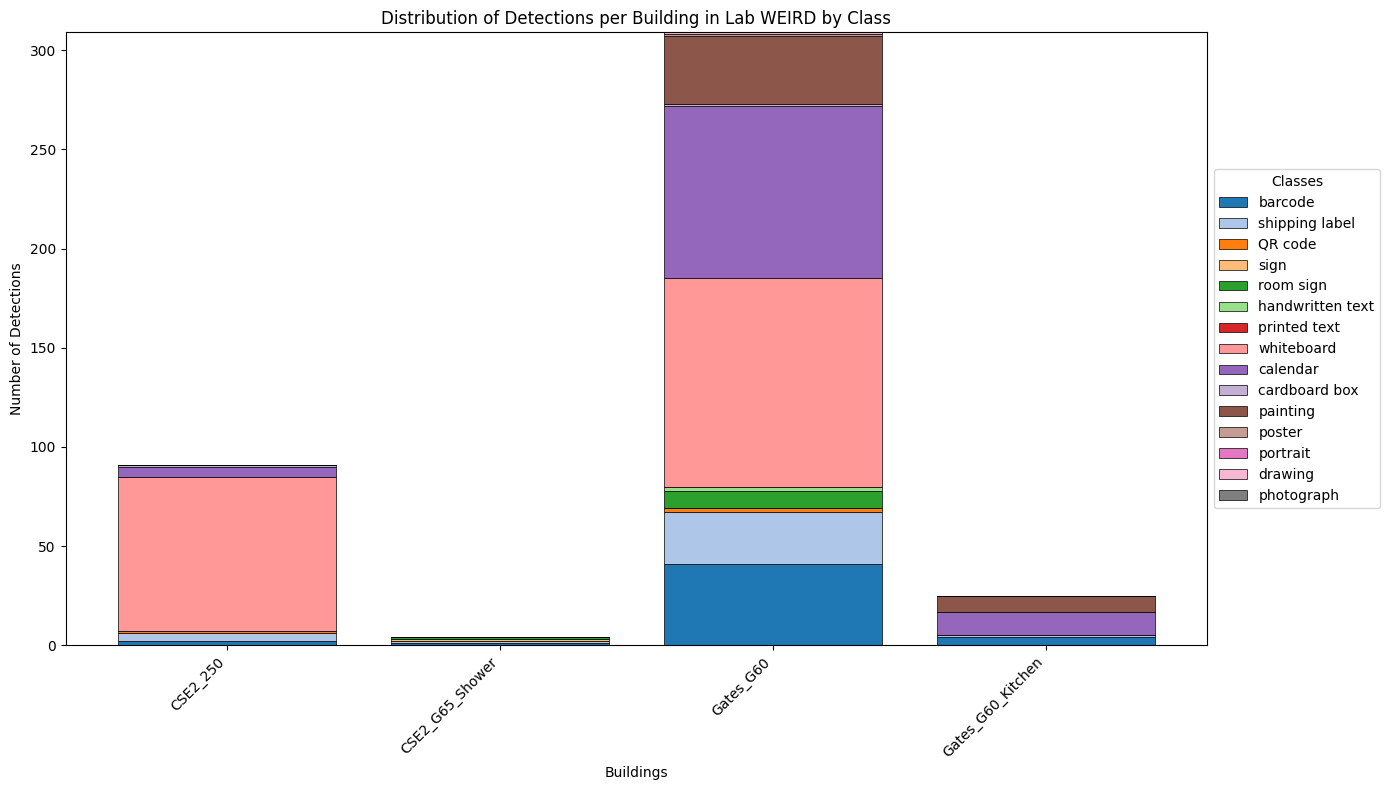

In [5]:
# For each lab, make a stacked bar chart showing the class distribution per building (stack shows buildings, colors show classes)
for lab in labs:
    building_list = sorted(list(set(fp['building'] for fps in file_paths.values() for fp in fps if fp['lab'] == lab)))
    buildings = building_list
    # use colors per class (wrap with mod in case there are more classes than palette entries)
    colors = [plt.cm.tab20(i % 20) for i in range(len(class_names))]
    # bottom must match number of buildings
    stack_bottom = np.zeros(len(buildings))
    plt.figure(figsize=(14, 8))
    for i, class_name in enumerate(class_names):
        counts = np.array([sum(1 for fp in file_paths[class_name] if fp['lab'] == lab and fp['building'] == building) for building in buildings])
        plt.bar(buildings, counts, bottom=stack_bottom, label=class_name, color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)
        stack_bottom += counts
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Buildings")
    plt.ylabel("Number of Detections")
    plt.title(f"Distribution of Detections per Building in Lab {lab} by Class")
    plt.legend(title="Classes", bbox_to_anchor=(1, 0.5), loc='center left')
    plt.tight_layout()
    plt.show()

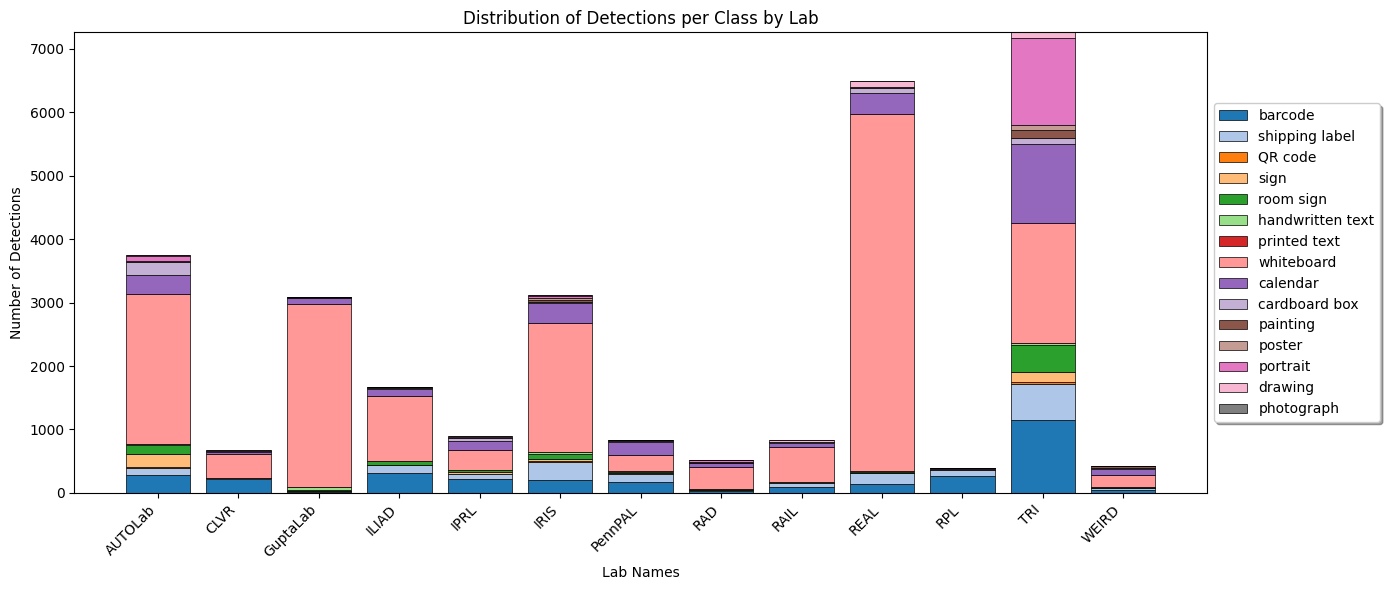

In [ ]:
# plot distribution of each class by lab (stacked bar chart), normalized by total images per lab
plt.figure(figsize=(14, 6))
lab_set = set()
for name in class_names:
    for fp in file_paths[name]:
        lab_set.add(fp['lab'])
lab_list = sorted(list(lab_set))
lab_indices = {lab: idx for idx, lab in enumerate(lab_list)}

# Compute total images per lab
total_images_per_lab = {}
for lab in lab_list:
    all_files = set()
    for name in class_names:
        for fp in file_paths[name]:
            if fp['lab'] == lab:
                all_files.add(fp['file_path'])
    total_images_per_lab[lab] = len(all_files)

bottom_counts = np.zeros(len(lab_list))
# Define hatching patterns for visual distinction
hatches = ['', '/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
for idx, name in enumerate(class_names):
    counts_by_lab = np.zeros(len(lab_list))
    for fp in file_paths[name]:
        lab_idx = lab_indices[fp['lab']]
        counts_by_lab[lab_idx] += 1
    # Normalize by total images per lab
    normalized_counts = counts_by_lab / np.array([total_images_per_lab[lab] for lab in lab_list])
    color = plt.cm.tab20(idx % 20)
    hatch = hatches[idx // 20] if idx // 20 < len(hatches) else hatches[-1]
    plt.bar(lab_list, normalized_counts, bottom=bottom_counts, label=name, color=color, edgecolor='black', hatch=hatch, linewidth=0.5)
    bottom_counts += normalized_counts
plt.xticks(rotation=45, ha='right')
plt.xlabel("Lab Names")
plt.ylabel("Normalized Number of Detections (per total images)")
plt.title("Normalized Distribution of Detections per Class by Lab")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()


In [7]:
def create_class_folder(class_name, file_list, base_output_dir="/usr/project/xtmp/bsc32/yoloe_class_folders", confidence_threshold=0.5):
    class_dir = Path(base_output_dir) / class_name
    class_dir.mkdir(parents=True, exist_ok=True)
    num_skipped = 0
    for entry in tqdm(file_list, desc=f"Creating symlinks for {class_name}", position=0, mininterval=0.5, dynamic_ncols=True):
        conf = entry.get('confidence', None)
        if conf is not None and conf < confidence_threshold:
            num_skipped += 1
            continue
        
        file_path = entry['file_path']
        relative_path = Path(entry['file_path']).relative_to(f"/usr/project/xtmp/bsc32/droid/")

        symlink_path = class_dir / relative_path
        
        symlink_path.parent.mkdir(parents=True, exist_ok=True)        
        try:
            os.symlink(file_path, symlink_path)
        except FileExistsError:
            pass
    print(f"Skipped {num_skipped} / {len(file_list)} entries.")


In [8]:
for class_name, files in file_paths.items():
    create_class_folder(class_name, files)
    
    

Creating symlinks for barcode:   0%|          | 0/3152 [00:00<?, ?it/s]

Skipped 0 / 3152 entries.


Creating symlinks for shipping label:   0%|          | 0/1687 [00:00<?, ?it/s]

Skipped 0 / 1687 entries.


Creating symlinks for QR code:   0%|          | 0/67 [00:00<?, ?it/s]

...

Skipped 0 / 1523 entries.


Creating symlinks for drawing:   0%|          | 0/301 [00:00<?, ?it/s]

Skipped 0 / 301 entries.


Creating symlinks for photograph: 0it [00:00, ?it/s]

Skipped 0 / 0 entries.


some sorta whiteboard: /usr/project/xtmp/bsc32/yoloe_class_folders/poster/IRIS/Gates/4901145574/Wed_Apr_19_10:14:52_2023/29838012/000001.png

BOX SOMETHIGN?? /usr/project/xtmp/bsc32/yoloe_class_folders/poster/TRI/TRI/7711955171/000008.png

Phone numba!! /usr/project/xtmp/bsc32/yoloe_class_folders/whiteboard/TRI/780_Shary_Ave/7212793711/Tue_Feb__6_15:46:42_2024/28451778/000001.png

Shipping label (with text tho) /usr/project/xtmp/bsc32/yoloe_class_folders/whiteboard/PennPAL/Penn_Levine_457/832284345/000012.png

Stanford Xerox message: /usr/project/xtmp/bsc32/yoloe_class_folders/whiteboard/IRIS/N/A/000008.png

Penn ID (Face Blurred): /usr/project/xtmp/bsc32/yoloe_class_folders/whiteboard/PennPAL/Penn_Levine_457/9044821029/000003.png

maybe a qr code: /usr/project/xtmp/bsc32/yoloe_class_folders/whiteboard/REAL/glen_bureau/9760960819/000004.png


Wasabi_tempura building in IPRL btw (studio apartment)

In [9]:
# Print all file paths for whiteboard in IRIS lab ending in 8.png
for entry in file_paths.get("whiteboard", []):
    if entry['lab'] == "IRIS" and entry['file_path'].endswith("8.png"):
        print(entry['file_path'])

/usr/project/xtmp/bsc32/droid/IRIS/Gates/5656414544/Thu_Apr_27_15:55:14_2023/19824535/000018.png
/usr/project/xtmp/bsc32/droid/IRIS/Gates/9228483020/Thu_May_11_15:30:46_2023/19824535/000018.png
/usr/project/xtmp/bsc32/droid/IRIS/Gates/8690198922/Wed_Apr_26_10:25:48_2023/19824535/000018.png
/usr/project/xtmp/bsc32/droid/IRIS/Gates/3526551049/Thu_Nov__2_15:43:02_2023/19824535/000018.png
/usr/project/xtmp/bsc32/droid/IRIS/Gates/3526551049/Thu_Nov__2_15:38:05_2023/19824535/000008.png
/usr/project/xtmp/bsc32/droid/IRIS/N/A/-1/Wed_Mar__8_18_54_30_2023/19824535/000008.png
